In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

df = pd.DataFrame()

In [32]:
apps = ["Facebook", "Instagram", "Skype", "Snapchat", "TikTok", "Twitter", "Viber", "WhatsApp", "Netflix", "Flipboard"]

for app in apps:
    app_df = pd.read_csv(f"files/{app}.csv")
    app_df['app'] = app
    df = pd.concat([df, app_df], ignore_index=True)

In [33]:
df.head(15)

,reviewId,content,score,app
0,437c0830-9a0e-4005-b13b-c4c03c4ef06c,It helps me communicate w my kids,5,Facebook
1,db6c59ec-2755-4ead-bc84-2fba101d71f0,Ok,4,Facebook
2,9700fff2-022e-42d8-998a-39f3f8500f51,Good app 👌,5,Facebook
3,bc746c52-1732-4def-a5c2-dc7682677b1b,Great but i cant download,5,Facebook
4,babe5691-4994-48d8-bd91-95fd55b7fe07,very nice,5,Facebook
5,3297b164-80f5-4f05-a419-1b71e3be9988,𝑽𝒆𝒓𝒚 𝒏𝒊𝒄𝒆,5,Facebook
6,c3dbabad-32f0-4d4a-bcd7-e047d26c0c10,MD.shahid,5,Facebook
7,04d86224-533a-4dcd-aa07-3057da35a4c7,I'm single,2,Facebook
8,152a9a2f-ac12-40fb-a222-095e5cf10ce6,walang kwenta,1,Facebook
9,c19a6559-902f-4145-85e6-0fc6fce5ed43,হাই,5,Facebook


In [34]:
df.describe()

,score
count,100000.000000
mean,3.614140
std,1.726152
min,1.000000
25%,1.000000
50%,5.000000
75%,5.000000
max,5.000000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   reviewId  100000 non-null  object
 1   content   99987 non-null   object
 2   score     100000 non-null  int64 
 3   app       100000 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.1+ MB


In [36]:
df = df.dropna()

In [37]:
import re
import string
import unicodedata
from cleantext import clean

def normalize_font(text):
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

def remove_emoji(text):
    return clean(text)

def clean_text(text):
    text = normalize_font(text)
    text = remove_emoji(text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [38]:
df['cleaned_content'] = df['content'].apply(clean_text)

In [39]:
df = df[df['cleaned_content'] != '']

In [40]:
df.head(15)

,reviewId,content,score,app,cleaned_content
0,437c0830-9a0e-4005-b13b-c4c03c4ef06c,It helps me communicate w my kids,5,Facebook,it helps me communicate w my kids
1,db6c59ec-2755-4ead-bc84-2fba101d71f0,Ok,4,Facebook,ok
2,9700fff2-022e-42d8-998a-39f3f8500f51,Good app 👌,5,Facebook,good app
3,bc746c52-1732-4def-a5c2-dc7682677b1b,Great but i cant download,5,Facebook,great but i cant download
4,babe5691-4994-48d8-bd91-95fd55b7fe07,very nice,5,Facebook,very nice
5,3297b164-80f5-4f05-a419-1b71e3be9988,𝑽𝒆𝒓𝒚 𝒏𝒊𝒄𝒆,5,Facebook,very nice
6,c3dbabad-32f0-4d4a-bcd7-e047d26c0c10,MD.shahid,5,Facebook,mdshahid
7,04d86224-533a-4dcd-aa07-3057da35a4c7,I'm single,2,Facebook,im single
8,152a9a2f-ac12-40fb-a222-095e5cf10ce6,walang kwenta,1,Facebook,walang kwenta
10,05c3a117-6c82-416d-b59a-237346979e6a,Round,5,Facebook,round


In [41]:
df.head(20)

,reviewId,content,score,app,cleaned_content
0,437c0830-9a0e-4005-b13b-c4c03c4ef06c,It helps me communicate w my kids,5,Facebook,it helps me communicate w my kids
1,db6c59ec-2755-4ead-bc84-2fba101d71f0,Ok,4,Facebook,ok
2,9700fff2-022e-42d8-998a-39f3f8500f51,Good app 👌,5,Facebook,good app
3,bc746c52-1732-4def-a5c2-dc7682677b1b,Great but i cant download,5,Facebook,great but i cant download
4,babe5691-4994-48d8-bd91-95fd55b7fe07,very nice,5,Facebook,very nice
5,3297b164-80f5-4f05-a419-1b71e3be9988,𝑽𝒆𝒓𝒚 𝒏𝒊𝒄𝒆,5,Facebook,very nice
6,c3dbabad-32f0-4d4a-bcd7-e047d26c0c10,MD.shahid,5,Facebook,mdshahid
7,04d86224-533a-4dcd-aa07-3057da35a4c7,I'm single,2,Facebook,im single
8,152a9a2f-ac12-40fb-a222-095e5cf10ce6,walang kwenta,1,Facebook,walang kwenta
10,05c3a117-6c82-416d-b59a-237346979e6a,Round,5,Facebook,round


In [42]:
df['content_status'] = df['score'].apply(lambda x: 1 if x >= 3 else 0)

In [43]:
df.head(5)

,reviewId,content,score,app,cleaned_content,content_status
0,437c0830-9a0e-4005-b13b-c4c03c4ef06c,It helps me communicate w my kids,5,Facebook,it helps me communicate w my kids,1
1,db6c59ec-2755-4ead-bc84-2fba101d71f0,Ok,4,Facebook,ok,1
2,9700fff2-022e-42d8-998a-39f3f8500f51,Good app 👌,5,Facebook,good app,1
3,bc746c52-1732-4def-a5c2-dc7682677b1b,Great but i cant download,5,Facebook,great but i cant download,1
4,babe5691-4994-48d8-bd91-95fd55b7fe07,very nice,5,Facebook,very nice,1


In [44]:
df_sample = df.sample(n=80000, random_state=42)
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 16831 to 45611
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   reviewId         80000 non-null  object
 1   content          80000 non-null  object
 2   score            80000 non-null  int64 
 3   app              80000 non-null  object
 4   cleaned_content  80000 non-null  object
 5   content_status   80000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 4.3+ MB


Используя sklearn

In [45]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df_sample['cleaned_content'])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(df_sample['content_status'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Accuracy: 0.85325
Precision: 0.850683368173674
Recall: 0.85325
F1: 0.8500913406527625


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [47]:
new_comment = "bad"
new_comment_vectorized = tfidf.transform([new_comment])
prediction = model.predict(new_comment_vectorized)
prediction

array([0])

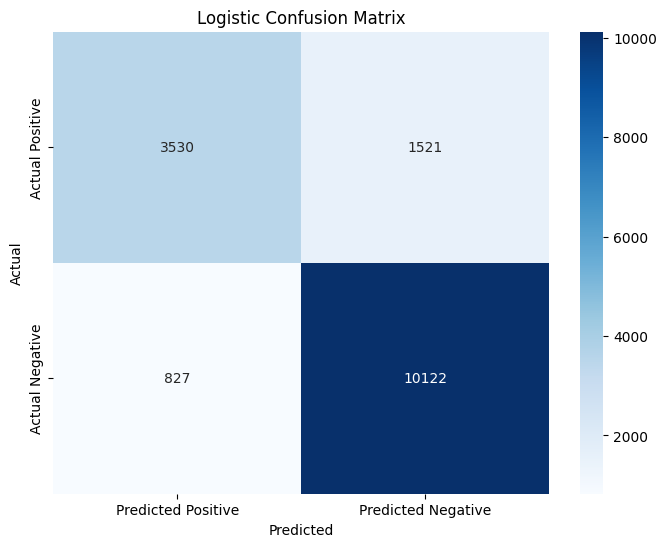

In [48]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Positive', 'Predicted Negative'], 
            yticklabels=['Actual Positive', 'Actual Negative'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Confusion Matrix')

plt.show()

In [49]:
df_sample = df.sample(n=80000, random_state=42)
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 16831 to 45611
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   reviewId         80000 non-null  object
 1   content          80000 non-null  object
 2   score            80000 non-null  int64 
 3   app              80000 non-null  object
 4   cleaned_content  80000 non-null  object
 5   content_status   80000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 4.3+ MB


In [50]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df_sample['cleaned_content'])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(df_sample['content_status'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
from sklearn.svm import SVC

model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train.ravel())

y_pred = model.predict(X_test)

recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

Accuracy: 0.852625
Precision: 0.8501869700631823
Recall: 0.852625
F1: 0.8505296192571283


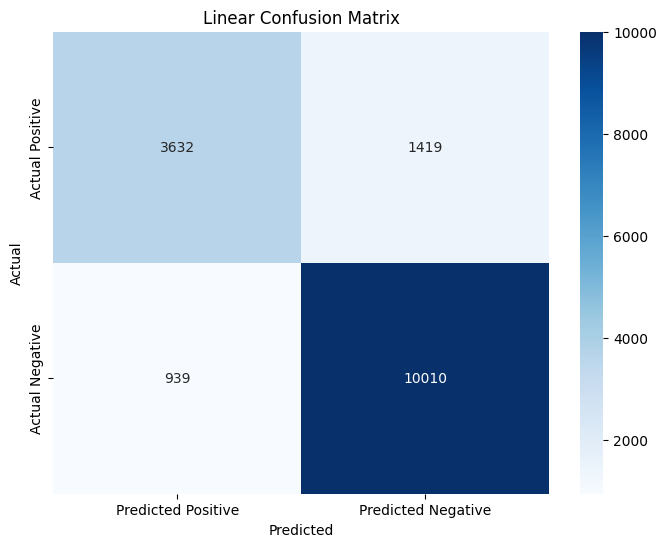

In [52]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Positive', 'Predicted Negative'], 
            yticklabels=['Actual Positive', 'Actual Negative'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Linear Confusion Matrix')

plt.show()

In [53]:
from sklearn.svm import SVC

model = SVC(kernel='poly',degree=2)
model.fit(X_train, y_train.ravel())

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

Accuracy: 0.8481875
Precision: 0.8454729120266492
Recall: 0.8481875
F1: 0.8443515770925072


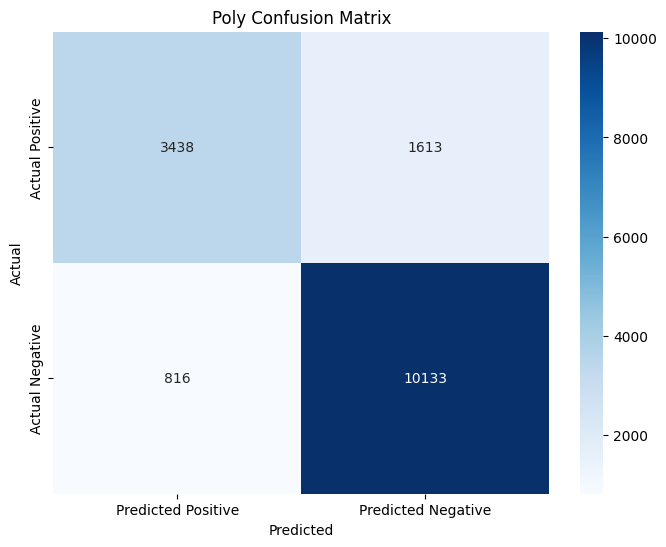

In [54]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Positive', 'Predicted Negative'], 
            yticklabels=['Actual Positive', 'Actual Negative'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Poly Confusion Matrix')

plt.show()

logistic: time 2.2s, accuracy 0.85
svc linear: time 6m 51s, accuracy 0.85
svc poly: time 14m 44.9s, accuracy 0.84